In [1]:
import tensorly as tl

tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = P300(resample=64)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
idc = meta['session'] == meta['session'][0]
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/usr/local/lib/python3.10/dist-packages/moabb/datasets/download.py:55: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_P

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
MNE_DATA is not already configured. It will be set to default location in the home directory - /root/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.797 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [5]:
from hoda.tensorize import hankel_tensor
X = epochs.get_data()
y = labels
print(X.shape)
X = hankel_tensor(X)
X.shape

(576, 16, 52)


/tmp/ipykernel_71/2316430803.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 27, 26)

In [6]:
from hoda.hoda import BTTDA


bttda = BTTDA(
    ranks=[None]*16,    
    hoda_params=dict(
            max_iter=256,
            tol=1e-8,
            init ='mlsvd',
            shrinkage='lw',
            toeplitz=(1,2,),
            taper=False,
            obj='rt',
            solver='lanczos',
            extra_train_info=False,
            verbose=True,
            delta=0.1,
    ),
    verbose=True,
    extra_train_info=True,
)

bttda.fit(X,y)

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

...

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

BTTDA(extra_train_info=True,
      hoda_params={'delta': 0.1, 'extra_train_info': False, 'forward': True,
                   'init': 'mlsvd', 'max_iter': 256, 'obj': 'rt', 'rank': None,
                   'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                   'toeplitz': (1, 2), 'tol': 1e-08, 'verbose': True},
      ranks=[None, None, None, None, None, None, None, None, None, None, None,
             None, None, None, None, None])

In [11]:
import pandas as pd

pd.DataFrame(bttda.train_info_)

,block,rank,mse,F_tr,F_rt
0,1,"(3, 6, 6)",0.875374,0.115473,0.009417
1,2,"(4, 5, 5)",0.763731,0.099285,0.011384
2,3,"(4, 6, 6)",0.724232,0.094768,0.013229
3,4,"(4, 5, 4)",0.710477,0.090973,0.015245
4,5,"(5, 5, 4)",0.691759,0.088999,0.016974
5,6,"(5, 5, 6)",0.652639,0.083288,0.019819
6,7,"(4, 4, 4)",0.634044,0.082762,0.021575
7,8,"(4, 4, 4)",0.623623,0.081750,0.022928
8,9,"(3, 3, 3)",0.619114,0.084704,0.023686
9,10,"(3, 3, 2)",0.616716,0.088672,0.024206


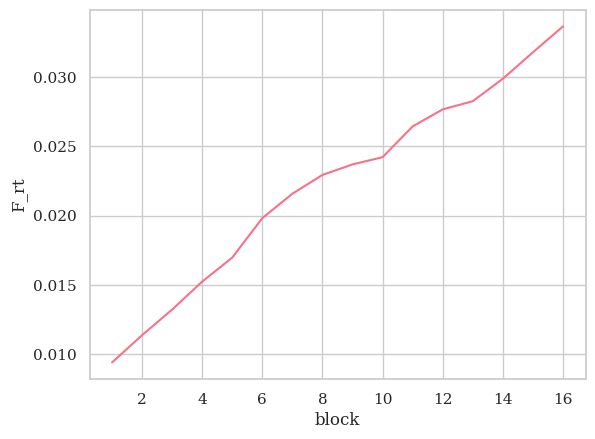

<Axes: xlabel='block', ylabel='mse'>

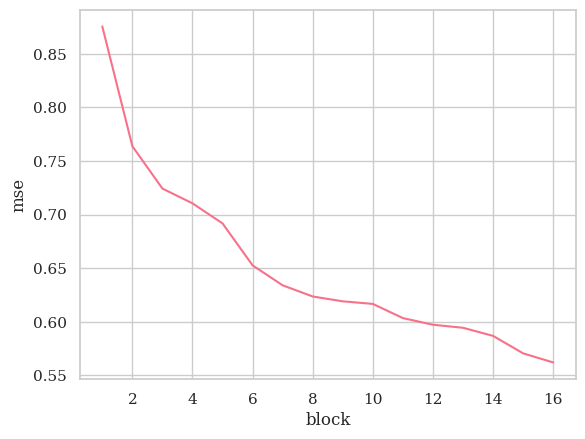

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=bttda.train_info_, x='block', y='F_rt')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='mse')

No projector specified for this dataset. Please consider the method self.add_proj.


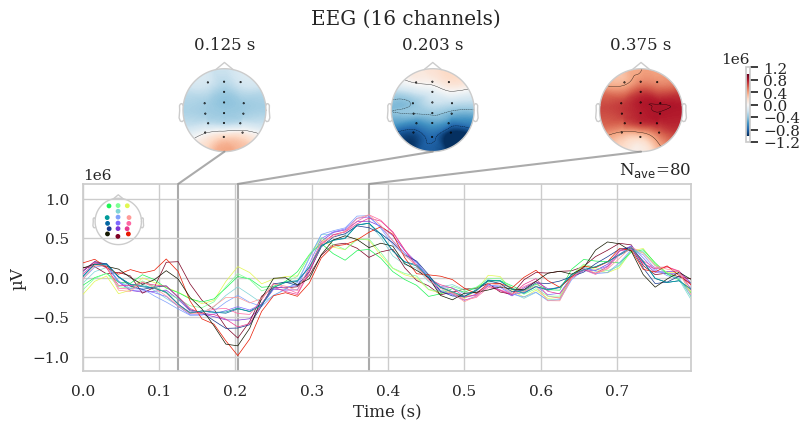

In [13]:
from mne import combine_evoked
import numpy as np
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
vmax = np.max(np.abs(contrast.data))*1.2*1e6
joint_args=dict(ts_args=dict(ylim=dict(eeg=[-vmax, vmax])))
_ = contrast.plot_joint(**joint_args)

/tmp/ipykernel_71/3955356239.py:7: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X_defl = hankel_tensor(epochs.get_data())
/tmp/ipykernel_71/3955356239.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = np.zeros_like(epochs_rec.get_data())


No projector specified for this dataset. Please consider the method self.add_proj.


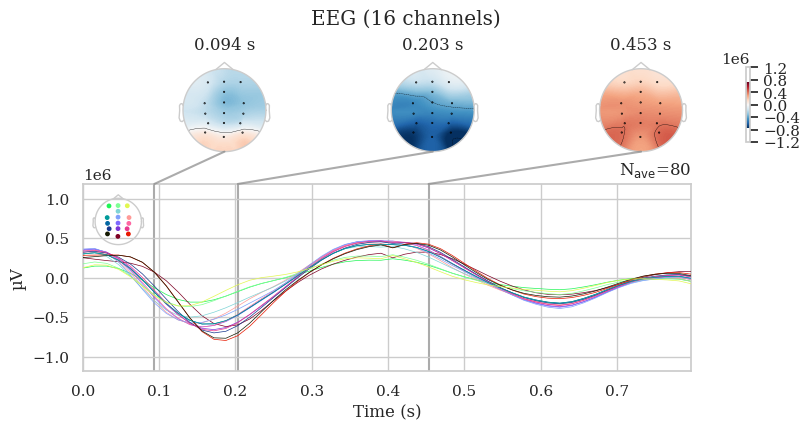

No projector specified for this dataset. Please consider the method self.add_proj.


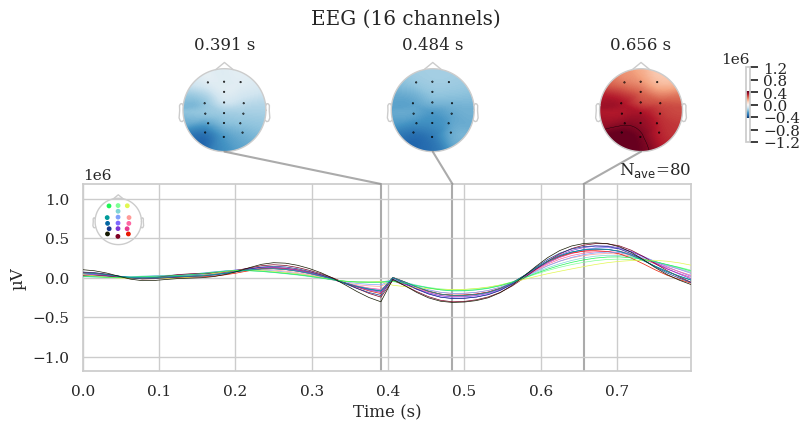

No projector specified for this dataset. Please consider the method self.add_proj.


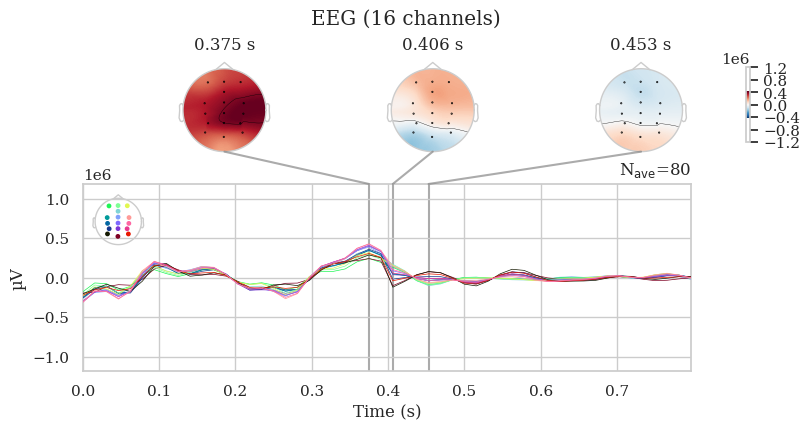

No projector specified for this dataset. Please consider the method self.add_proj.


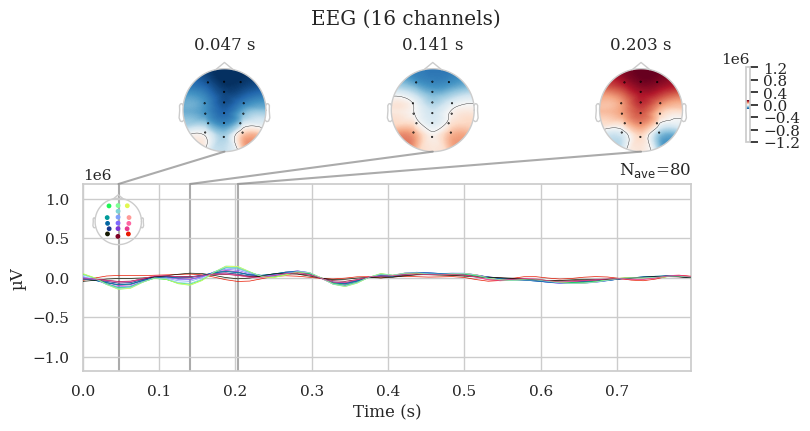

No projector specified for this dataset. Please consider the method self.add_proj.


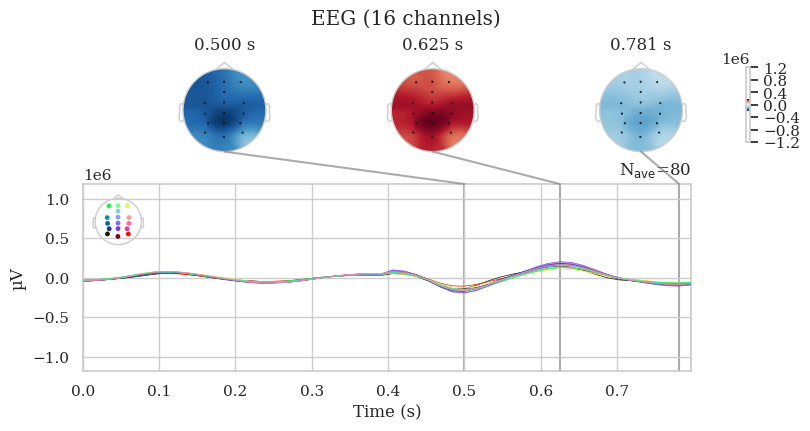

No projector specified for this dataset. Please consider the method self.add_proj.


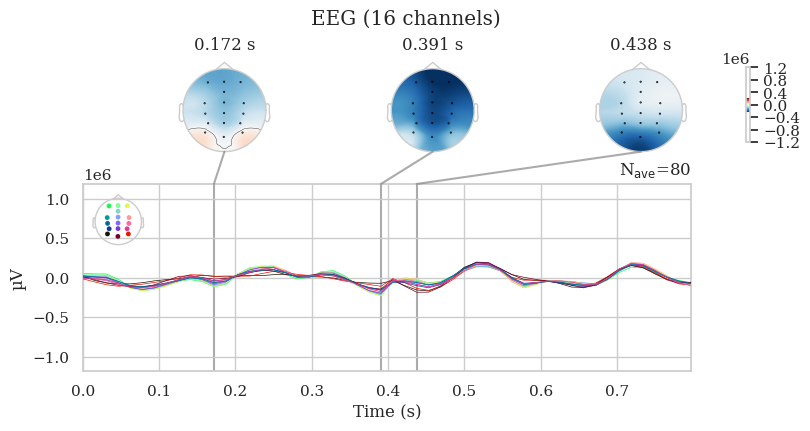

No projector specified for this dataset. Please consider the method self.add_proj.


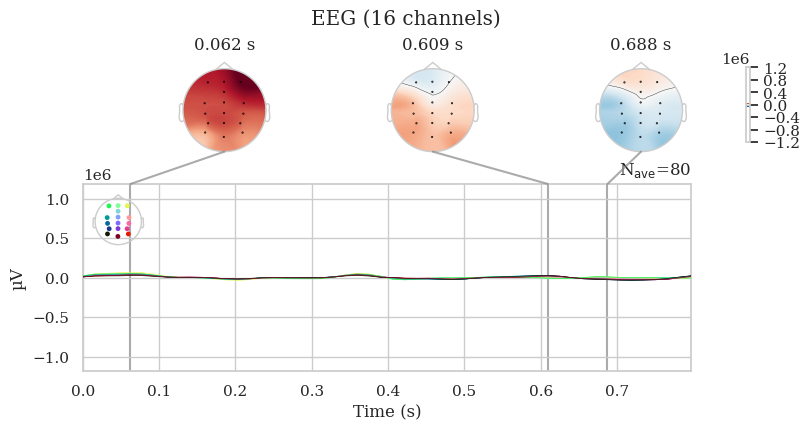

No projector specified for this dataset. Please consider the method self.add_proj.


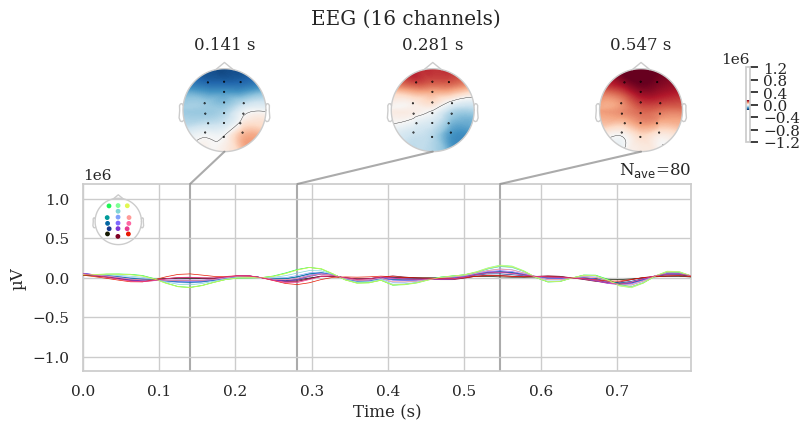

No projector specified for this dataset. Please consider the method self.add_proj.


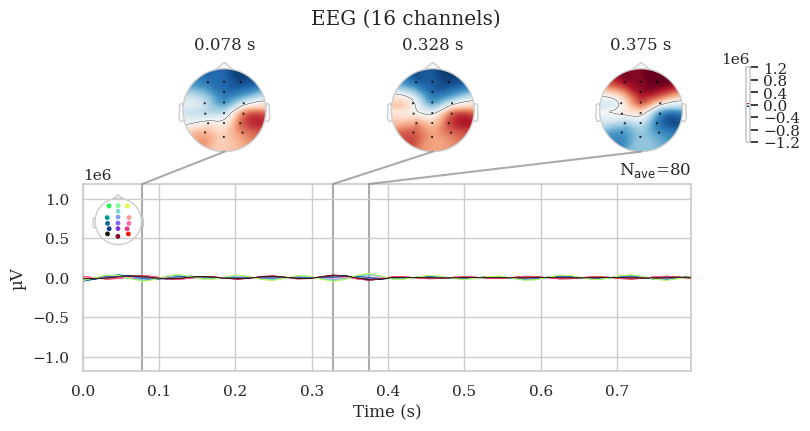

No projector specified for this dataset. Please consider the method self.add_proj.


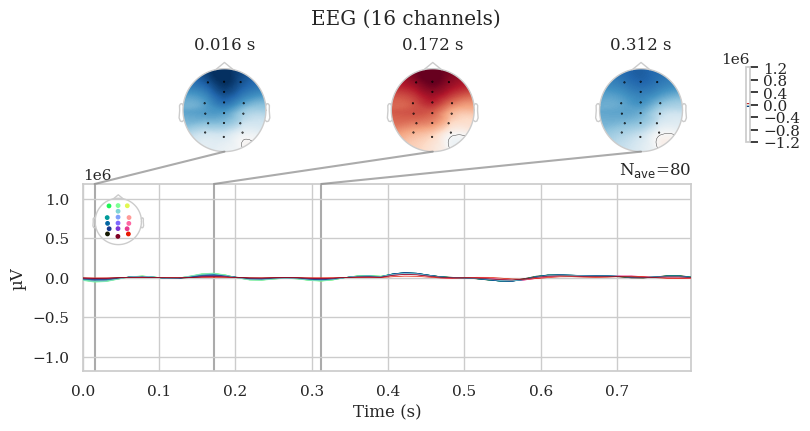

No projector specified for this dataset. Please consider the method self.add_proj.


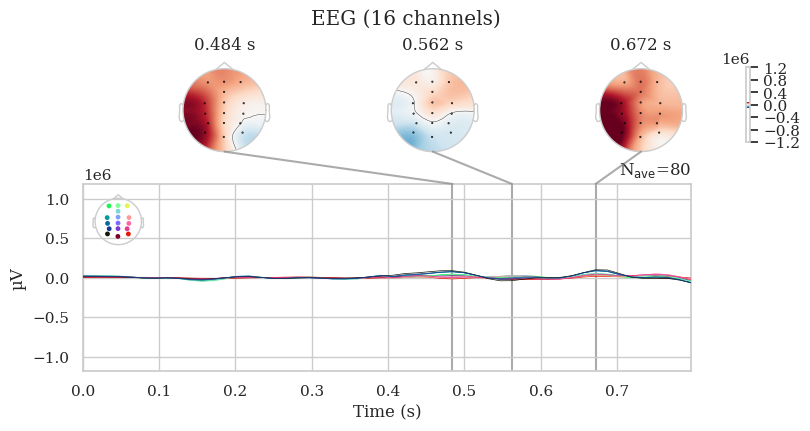

No projector specified for this dataset. Please consider the method self.add_proj.


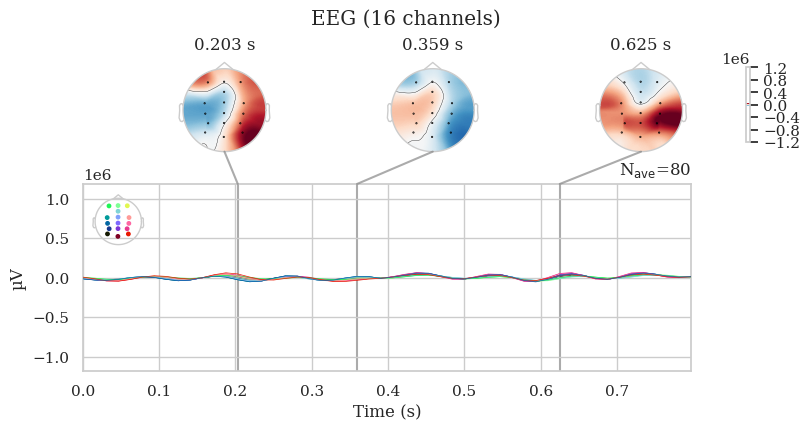

No projector specified for this dataset. Please consider the method self.add_proj.


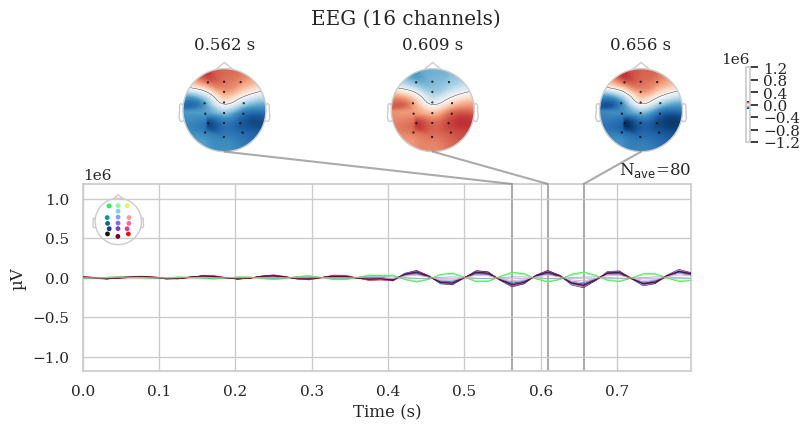

No projector specified for this dataset. Please consider the method self.add_proj.


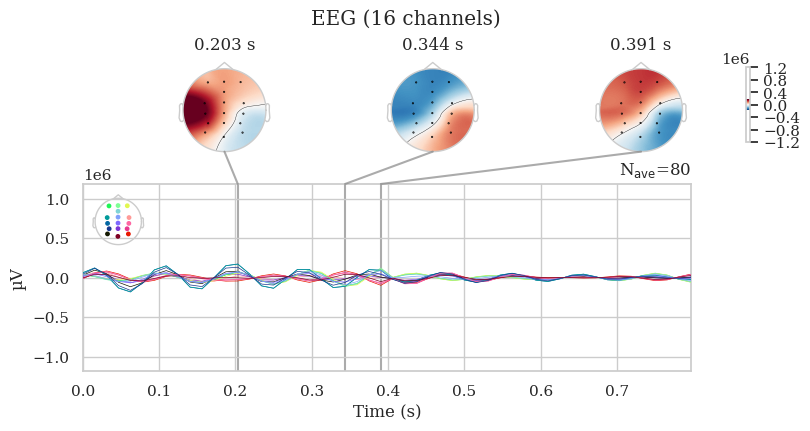

No projector specified for this dataset. Please consider the method self.add_proj.


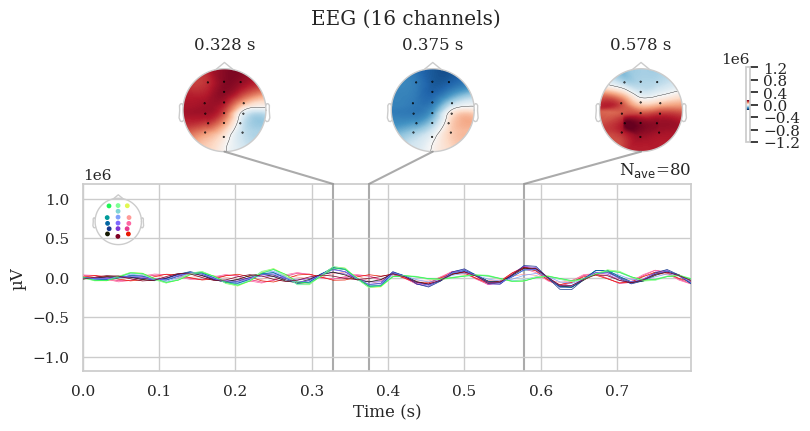

No projector specified for this dataset. Please consider the method self.add_proj.


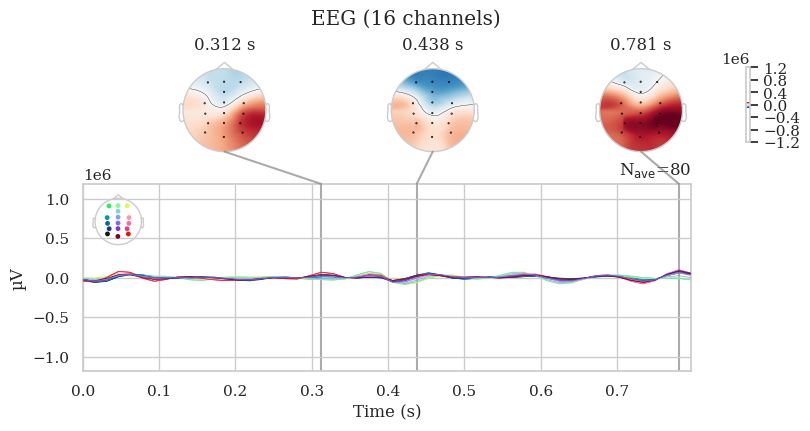

In [14]:
from mne import combine_evoked
from mne.viz import plot_compare_evokeds
from hoda.tensorize import hankel_tensor_inv
import numpy as np


X_defl = hankel_tensor(epochs.get_data())
epochs_rec = epochs.copy()
epochs_rec._data = np.zeros_like(epochs_rec.get_data())
evokeds = dict()
for b in range(len(bttda.blocks_)):
    epochs_block_rec = epochs.copy()
    Xb =  tl.to_numpy(bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(X_defl)))
    epochs_block_rec._data =hankel_tensor_inv(Xb)
    X_defl -= Xb
    epochs_rec._data += epochs_block_rec._data
    
    target_block_rec = epochs_block_rec['Target'].average()
    non_target_block_rec = epochs_block_rec['NonTarget'].average()
    contrast_block_rec = combine_evoked([target_block_rec,non_target_block_rec], weights=[1,-1])
    evokeds[f'block {b}'] =contrast_block_rec
    contrast_block_rec.plot_joint(**joint_args)